# Demonstration of training an LSTM to predict SMBH mass at a fixed halo binding energy at z=0 from timeseries data, then using TimeSHAP to analyse model behaviour

In [ ]:
import numpy as np
import pandas as pd
import h5py as h5
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
import swiftsimio as sw
from astropy.cosmology import FlatLambdaCDM
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import optuna
from tqdm import tqdm
optuna.logging.set_verbosity(optuna.logging.WARNING)

import os
import sys
sys.path.append("OU-Example-Code/COLIBRE-Research")

from Util.spearman_window import spearman_track_ebind


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import altair as alt
alt.data_transformers.disable_max_rows()

from timeshap.wrappers import TorchModelWrapper
from timeshap.explainer import calc_local_report

import optuna
import torch
import torch.nn as nn

# Use custom matplotlib template
plt.style.use('mnras_mpl.stylesheet')
cosmology = FlatLambdaCDM(H0=68.10, Om0=0.3089)
h = 0.681
Msun = 1.98841e33
yr = 3.154e7
Mpc = 3.086e24 
kpc = 3.086e21
G = 6.67e-8
km = 1e5
kms = 1e5
cgs_conv_mass = 1.989e+43
cgs_conv_vel = 100000
cgs_conv_radius = 3.085678e+21
cgs_conv_factor_ebind = 1.98841e+53

base_path = COLIBRE_path
run_l200m6 = 'L200_m6/Thermal'
run_l200m6_DMO = 'L200_m6/DMO'

save_path = save_path

In [ ]:
# Bijective indices between DMO and Hydro sims
with h5.File(f'DMO_Hydro_Matching.hdf5', 'r') as fi:
    bijective_idx_DMO = fi['Bijective_DMO_Indices'][()]
    bijective_idx_Hydro = fi['Bijective_Hydro_Indices'][()]
    consistent_DMOtoHydro = fi['consistent_DMOtoHydro'][()]
    consistent_HydrotoDMO = fi['consistent_HydrotoDMO'][()]
fi.close()

# DMO binding energy
with h5.File(f'DMO_Binding_Energies.hdf5', 'r') as fi:
    ebind = np.log10(fi['TotalBindingEnergy'][()])
fi.close()

# Redshifts for snapshots only
with h5.File(f'{save_path}/M200_kappa_histories.hdf5', 'r') as fi:
    redshifts_snaps = fi['Redshifts'][()]
fi.close()

# Redshifts for snapshots and snipshots, cropped to match snapshot redshifts after z=2
with h5.File(f'{save_path}/Galaxy_timeseries.hdf5', 'r') as fi:
    mask_soap = fi['mask_ebind'][()]
    track_IDs = fi['Track_IDs'][()]
    redshifts_all = fi['Redshifts'][()]
    redshift_mask = np.isin(redshifts_all[51:], redshifts_snaps)
    redshifts = np.concatenate((redshifts_all[:51], redshifts_all[51:][redshift_mask])) 
    mask_z = np.isin(redshifts_all, redshifts)
    cropped_track_IDs = fi['Track_IDs'][()]
fi.close()


# Load galaxy/halo properties and order from high -> low z
# Clip snipshots at z > 2
with h5.File(f'{save_path}/Galaxy_timeseries.hdf5', 'r') as fi:
    track_IDs = fi['Track_IDs'][()]
    
    m200 = fi['M200_Tracks'][()][:,mask_z][:,::-1]
    mbh = fi['MBH_Tracks'][()][:,mask_z][:,::-1]
    kappa_stars = fi['Kappa_Stars_Tracks'][()][:,mask_z][:,::-1]
    kappa_gas = fi['Kappa_Gas_Tracks'][()][:,mask_z][:,::-1]
    psi_3kpc = fi['Misalignment_3kpc_Tracks'][()][:,mask_z][:,::-1]
    psi_30kpc = fi['Misalignment_30kpc_Tracks'][()][:,mask_z][:,::-1]
    psi_2r50 = fi['Misalignment_2r50_Tracks'][()][:,mask_z][:,::-1]
    f_gas_3kpc = fi['f_Gas_3kpc_Tracks'][()][:,mask_z][:,::-1]
    f_gas_30kpc = fi['f_Gas_30kpc_Tracks'][()][:,mask_z][:,::-1]
    f_gas_100kpc = fi['f_Gas_100kpc_Tracks'][()][:,mask_z][:,::-1]
    f_gas_r200 = fi['f_Gas_R200_Tracks'][()][:,mask_z][:,::-1]
fi.close()



redshift_mask = np.isin(redshifts_all[51:], redshifts_snaps)
z = np.concatenate((redshifts_all[:51], redshifts_all[51:][redshift_mask]))[::-1]

ebind = ebind[mask_soap]
print(m200.shape, ebind.shape)

# Load swiftsimio objects for Hydro and DMO runs
data_l200m6 = sw.load(f'{base_path}/{run_l200m6}/SOAP-HBT/halo_properties_0127.hdf5')
data_l200m6_DMO = sw.load(f'{base_path}/{run_l200m6_DMO}/SOAP-HBT/halo_properties_0127.hdf5')

(31364, 89) (31364,)


In [ ]:
n_samples = len(mbh)
time_mask = 1   # Set > 0 to ignore the final n timesteps in the time-series
n_timesteps = len(z) - time_mask
n_features = 7
master_idx = np.arange(n_samples)   # Tracks the original indices of the galaxies before any filtering

# Initialise 3D array
X = np.full((n_samples, n_timesteps, n_features), -10.0, dtype=np.float32)
X[:,:,0] = m200[:,:-time_mask]
X[:,:,1] = kappa_gas[:,:-time_mask]
X[:,:,2] = kappa_stars[:,:-time_mask]
X[:,:,3] = f_gas_3kpc[:,:-time_mask]
X[:,:,4] = f_gas_r200[:,:-time_mask]
X[:,:,5] = psi_30kpc[:,:-time_mask]
X[:,:,6] = psi_2r50[:,:-time_mask]


# Mask nans and infs
for i in range(n_features):
    X[:,:,i][np.isinf(X[:,:,i])] = -10
    X[:,:,i][np.isneginf(X[:,:,i])] = -10
    X[:,:,i][np.isnan(X[:,:,i])] = -10
    
mbh[np.isinf(mbh)] = -10
mbh[np.isnan(mbh)] = -10
mbh[np.isneginf(mbh)] = -10
    
# Random sample out half of the low-mass galaxies to balance the dataset
# This is currently arbitrary and a more appropriate downsampling of low-mass galaxies should be implemented
low_mass_mask = np.argwhere(X[:,-1,0] < 12.5)
low_mass_mask = low_mass_mask[np.random.choice(len(low_mass_mask), int(0.5*len(low_mass_mask)), replace=False)]

X = np.delete(X, low_mass_mask, axis=0)
mbh = np.delete(mbh, low_mass_mask, axis=0)
ebind = np.delete(ebind, low_mass_mask, axis=0)
master_idx = np.delete(master_idx, low_mass_mask, axis=0)

# Sort by Ebind for LOWESS median calculation
sort_idx = np.argsort(ebind)
X = X[sort_idx]
mbh = mbh[sort_idx]
ebind = ebind[sort_idx]
master_idx = master_idx[sort_idx]

print(X.shape, mbh.shape, ebind.shape)

# Calculate LOWESS fit to MBH so we can remove the obvious outliers
# Basically target all BHs that are very likely to be a result of failed particle/halo tracking, rather than a physical process
lowess_mbh_z0 = lowess(mbh[:,-1], ebind, return_sorted=False, frac=0.2, it=3)
drop_idx = [i for i in range(len(X)) if lowess_mbh_z0[i] - mbh[i,-1] > 1.0]
y = mbh[:,-1] - lowess_mbh_z0
mbh = np.delete(mbh, drop_idx, axis=0)
lowess_mbh_z0 = np.delete(lowess_mbh_z0, drop_idx, axis=0)
X = np.delete(X, drop_idx, axis=0)
y = np.delete(y, drop_idx, axis=0)
ebind = np.delete(ebind, drop_idx, axis=0)
master_idx = np.delete(master_idx, drop_idx, axis=0)

print(X.shape, y.shape, ebind.shape)
print(np.unique(np.isnan(X)), np.unique(np.isnan(y)))

# Split into train, val, test
n_filtered = len(y)
pos_idx = np.arange(n_filtered)

X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(X, y, pos_idx, test_size=0.2, shuffle=True, random_state=42)
X_train, X_val, y_train, y_val, pos_train, pos_val = train_test_split(X_train, y_train, pos_train, test_size=0.2, shuffle=True, random_state=42)

# Keep the master indices for each split
master_idx_train = master_idx[pos_train]
master_idx_test  = master_idx[pos_test]
master_idx_val = master_idx[pos_val]

# Calculate the overmassive and undermassive thresholds for Delta MBH
pct_high = np.percentile(y_test, 80)
pct_low  = np.percentile(y_test, 20)

over_mask  = y_test >= pct_high
under_mask = y_test <= pct_low

# Positional indices for over- and under-massive black holes within X_test
over_pos_in_test  = np.where(over_mask)[0]
under_pos_in_test = np.where(under_mask)[0]

ebind_test = ebind[pos_test]

# Split the test set into three Ebind bins for use with TimeSHAP 
ebind_bins = {
    'low':  (58.0, 59.5),
    'mid':  (60, 60.5),
    'high': (61.0, 65.0),
}

# Masks for each Ebind bin
ebind_masks = {
    name: (ebind_test >= lo) & (ebind_test < hi)
    for name, (lo, hi) in ebind_bins.items()
}

# Positional indices within X_test for each bin
ebind_pos = {name: np.where(mask)[0] for name, mask in ebind_masks.items()}

X_ebind = {name: X_test[pos] for name, pos in ebind_pos.items()}
y_ebind = {name: y_test[pos] for name, pos in ebind_pos.items()}
master_ebind = {name: master_idx_test[pos] for name, pos in ebind_pos.items()}

# Create combined subsets for over/under-massive black holes within each Ebind bin
combined = {}
for bh_label, bh_pos in [('over', over_pos_in_test),
                           ('under', under_pos_in_test)]:
    for eb_label, (lo, hi) in ebind_bins.items():
        eb_test_vals = ebind_test[bh_pos]
        combined_mask = (eb_test_vals >= lo) & (eb_test_vals < hi)
        combined_pos = bh_pos[combined_mask]

        combined[f'{bh_label}_{eb_label}'] = {
            'X': X_test[combined_pos],
            'y': y_test[combined_pos],
            'master_idx': master_idx_test[combined_pos],
            'pos': combined_pos,
        }


print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

# Copy arrays to avoid overwriting
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()
combined_scaled = {name: d['X'].copy() for name, d in combined.items()}


# Scale each feature independently using StandardScaler, ignoring the -10 values
N, T, F = X_train.shape
valid_train_mask = np.zeros((N, T, F), dtype=np.float32)
valid_val_mask = np.zeros((X_val.shape[0], T, F), dtype=np.float32)
valid_test_mask = np.zeros((X_test.shape[0], T, F), dtype=np.float32)

for f in range(F):
    print(f)
    scaler = StandardScaler()
    
    # Train
    feature_train = X_train[:,:,f].flatten()
    valid_mask = feature_train > -10
    feature_train_scaled = np.zeros_like(feature_train)
    feature_train_scaled[valid_mask] = scaler.fit_transform(feature_train[valid_mask].reshape(-1,1)).flatten()
    feature_train_scaled[~valid_mask] = 0.0
    X_train_scaled[:,:,f] = feature_train_scaled.reshape(N, T)
    valid_train_mask[:,:,f] = valid_mask.reshape(N, T)
    
    # Val
    feature_val = X_val[:,:,f].flatten()
    valid_mask_val = feature_val > -10
    feature_val_scaled = np.zeros_like(feature_val)
    feature_val_scaled[valid_mask_val] = scaler.transform(feature_val[valid_mask_val].reshape(-1,1)).flatten()
    X_val_scaled[:,:,f] = feature_val_scaled.reshape(X_val.shape[0], T)
    valid_val_mask[:,:,f] = valid_mask_val.reshape(X_val.shape[0], T)
    
    # Test
    feature_test = X_test[:,:,f].flatten()
    valid_mask_test = feature_test > -10
    feature_test_scaled = np.zeros_like(feature_test)
    feature_test_scaled[valid_mask_test] = scaler.transform(feature_test[valid_mask_test].reshape(-1,1)).flatten()
    X_test_scaled[:,:,f] = feature_test_scaled.reshape(X_test.shape[0], T)
    valid_test_mask[:,:,f] = valid_mask_test.reshape(X_test.shape[0], T)

    for name in combined_scaled:
        flat  = combined[name]['X'][:,:,f].flatten()
        valid = flat > -10
        out = np.zeros_like(flat)
        out[valid] = scaler.transform(flat[valid].reshape(-1, 1)).flatten()
        combined_scaled[name][:,:,f] = out.reshape(combined[name]['X'].shape[0], T)
        


X_train_valid = np.where(X_train_scaled != 0.0, X_train_scaled, np.nan)
average_event = np.nanmean(X_train_valid, axis=0)   # (T, F)
average_event = np.nan_to_num(average_event, nan=0.0)

# Concatenate mask as extra input channels
X_train_scaled = np.concatenate([X_train_scaled, valid_train_mask], axis=2)  # (N, T, 2F)
X_val_scaled = np.concatenate([X_val_scaled, valid_val_mask], axis=2)
X_test_scaled = np.concatenate([X_test_scaled, valid_test_mask], axis=2)

print("average_event shape:", average_event.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1,1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1)).flatten()

(17302, 84, 7) (17302, 89) (17302,)
(17269, 84, 7) (17269,) (17269,)
[False] [False]
(11052, 84, 7) (2763, 84, 7) (3454, 84, 7)
(11052,) (2763,) (3454,)
0
1
2
3
4
5
6
average_event shape: (84, 7)


/tmp/ipykernel_430411/478511132.py:203: RuntimeWarning: Mean of empty slice
  average_event = np.nanmean(X_train_valid, axis=0)   # (T, F)


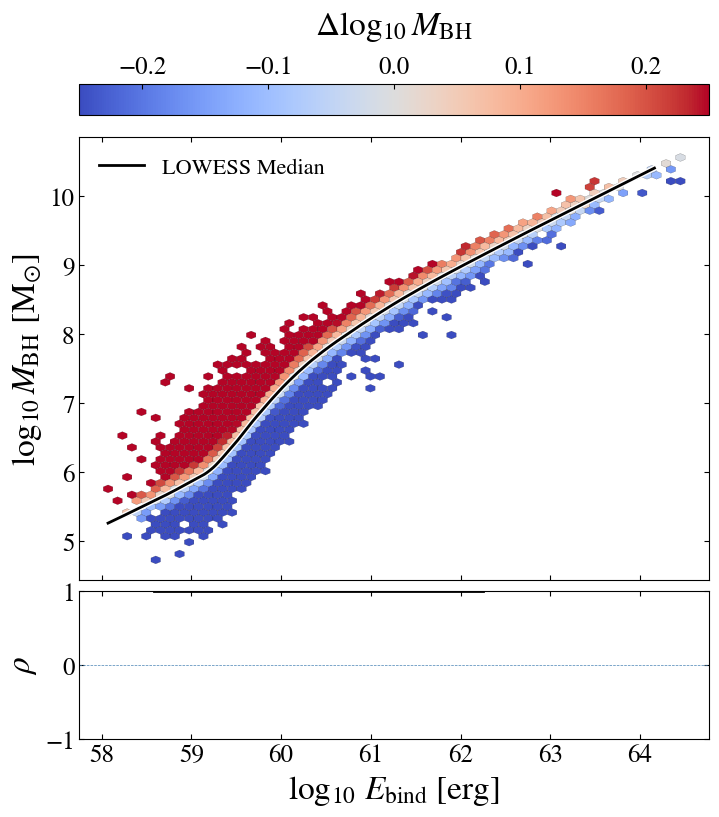

In [6]:
# Sanity check by plotting MBH vs Ebind and the Spearman correlation, which should be 1 at all times by construction

ebind_bins, sr_arr_mbh, p_arr_mbh = spearman_track_ebind(y, y, ebind)

fig, ax = plt.subplots(2,1, figsize=(7,8), gridspec_kw={'height_ratios':[3,1]}, sharex=True, layout='compressed')

hex = ax[0].hexbin(ebind, mbh[:,-1], C=y, reduce_C_function=np.mean, edgecolors='k', linewidth=0.1, cmap='coolwarm', gridsize=60, vmin=-0.25, vmax=0.25)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top')
cb.set_label('$\\Delta {\\log_{10}} M_{\\rm BH}$', fontsize=24, labelpad=15)
ax[0].plot(ebind[:-5], lowess_mbh_z0[:-5], lw=4, c='w')
ax[0].plot(ebind[:-5], lowess_mbh_z0[:-5], lw=2, c='k', label='LOWESS Median')
ax[0].set_ylabel('${\\log_{10}} M_{\\rm BH}$ [$\\rm M_{\\odot}$]')
ax[0].tick_params(axis='x', which='both', top=True, bottom=True)
ax[0].tick_params(axis='y', which='both', left=True, right=True)
ax[0].legend(fontsize=16, loc='upper left')
hex.set_rasterized(True)

ax[1].plot(ebind_bins, sr_arr_mbh, lw=2, c='k')
ax[1].axhline(0, ls='--', c='steelblue', lw=0.5)
ax[1].set_ylim(-1,1)
ax[1].set_xlabel('${\\log_{10}} \\, E_{\\rm bind}$ [erg]')
ax[1].set_ylabel('$\\rho$')
ax[1].tick_params(axis='x', which='both', top=True, bottom=True)
ax[1].tick_params(axis='y', which='both', left=True, right=True)
plt.show()

In [ ]:
class LSTMRegressor(nn.Module):
    ''' 
    Create the LSTM class for predicting Delta log(MBH) at z=0
    input_dim -> Number of features
    hidden_dim -> Size of the hidden state in the LSTM (bigger = more complex)
    num_layers -> Number of layers in the LSTM (bigger = more complex)
    bidirectional -> Enables bidirectionality, where the model looks forwards and backwards through time
    '''
    def __init__(self, input_dim, hidden_dim, num_layers=1, bidirectional=False):
        super().__init__()

        self.num_directions = 2 if bidirectional else 1 # bidirectionality most likely not useful for this problem

        # Define the LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        # Single continuous output
        self.output_layer = nn.Linear(hidden_dim * self.num_directions, 1)

    def forward(self, x):
        """
        x: (batch_size, time_steps, input_dim)
        """
        
        # Pass the input through the LSTM layer
        lstm_out, _ = self.lstm(x)

        # Use last timestep representation
        last_hidden = lstm_out[:, -1, :]

        # Pass through the output layer to get the final prediction
        y_pred = self.output_layer(last_hidden)
        return y_pred

In [10]:
def objective(trial):

    # Hyperparameters to tune
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    # dropout = trial.suggest_float('dropout', 0.1, 0.5)


    # Initialisation
    input_dim = X_train_scaled.shape[2]     # Feature Dimension
    timesteps = X_train_scaled.shape[1]     # Time Dimension
    
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Convert scaled train and validation sets to PyTorch tensors and move to device
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)

    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)
    
    
    # Initialise Model
    model = LSTMRegressor(
        input_dim=input_dim,    # Number of features
        hidden_dim=hidden_dim,  # Size of hidden state in LSTM
        num_layers=n_layers,    # Number of LSTM layers
        bidirectional=False     # bidirectional flag
    ).to(device)                # Move model to device (GPU or CPU)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)


    # Training loop 
    n_epochs = 50   # shorter for Optuna
    
    for epoch in range(n_epochs):
        # Enable train mode and shuffle the training data
        model.train()
        perm = torch.randperm(X_train_tensor.size(0))

        # Batch train the model
        for i in range(0, X_train_tensor.size(0), batch_size):
            idx = perm[i:i+batch_size]
            x_batch = X_train_tensor[idx]
            y_batch = y_train_tensor[idx].view(-1, 1)

            optimizer.zero_grad()   # Reset gradients
            preds = model(x_batch)  # Get predictions for this batch
            loss = criterion(preds, y_batch)    # Compute loss
            loss.backward()     # Backpropagate the loss
            optimizer.step()    # Update model parameters

        # Enable evaluation mode and compute validation loss with gradient tracking disabled
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_tensor)     # Validation predictions
            val_loss = criterion(
                val_preds,
                y_val_tensor.view(-1, 1)
            ).item()    # Compute validation loss

        # Pruning (early stopping for bad trials)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_loss


In [11]:
# Create an Optuna study to optimise the LSTM hyperparameters
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),    # Fix random seed for reproducibility
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)   # Use median pruning to stop unpromising trials early
)

# Run the hyperparameter optimisation on the study
study.optimize(objective, n_trials=5, show_progress_bar=True)   # Run 15+ trials for a thorough search, test with 5 for speed

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
# Initialise input parameters for LSTM
input_dim = X_train_scaled.shape[2]     # Feature Dimension
timesteps = X_train_scaled.shape[1]     # Time Dimension
epochs = 100
batch_size = study.best_params['batch_size']


# Model, loss, optimizer
model = LSTMRegressor(
    input_dim=input_dim,
    hidden_dim=study.best_params['hidden_dim'],
    num_layers=study.best_params['n_layers'],
    bidirectional=False
)

criterion = nn.MSELoss()  # regression loss
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'], weight_decay=1e-4)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)


# Lists to store losses
train_losses = []
val_losses = []

# Early stopping setup
patience = 15
min_delta = 1e-4
best_val_loss = np.inf
best_state = None
wait = 0

# Training loop
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.size(0))
    batch_loss = []

    for i in range(0, X_train_tensor.size(0), batch_size):
        idx = perm[i:i+batch_size]
        x_batch = X_train_tensor[idx]
        y_batch = y_train_tensor[idx].view(-1, 1)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())

    # Average training loss over batches
    avg_train_loss = np.mean(batch_loss)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train_tensor)
        train_preds_np = train_preds.cpu().numpy().flatten()
        train_labels_np = y_train_tensor.cpu().numpy().flatten()
        val_preds = model(X_val_tensor)
        val_preds_np = val_preds.cpu().numpy().flatten()
        val_labels_np = y_val_tensor.cpu().numpy().flatten()

    val_loss = np.mean((val_preds_np - val_labels_np) ** 2)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train MSE = {avg_train_loss:.3f} | "
        f"Validation MSE = {val_loss:.3f} | "
        f"Train RMSE = {np.sqrt(avg_train_loss):.3f} | "
        f"Validation RMSE = {np.sqrt(val_loss):.3f}"
    )

    # Early stopping check
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

# Restore best weights
model.load_state_dict(best_state)

Epoch 001 | Train MSE = 0.799 | Validation MSE = 0.639 | Train RMSE = 0.894 | Validation RMSE = 0.800
Epoch 002 | Train MSE = 0.558 | Validation MSE = 0.460 | Train RMSE = 0.747 | Validation RMSE = 0.678
Epoch 003 | Train MSE = 0.447 | Validation MSE = 0.425 | Train RMSE = 0.669 | Validation RMSE = 0.652
Epoch 004 | Train MSE = 0.423 | Validation MSE = 0.404 | Train RMSE = 0.651 | Validation RMSE = 0.636
Epoch 005 | Train MSE = 0.406 | Validation MSE = 0.378 | Train RMSE = 0.637 | Validation RMSE = 0.615
Epoch 006 | Train MSE = 0.394 | Validation MSE = 0.372 | Train RMSE = 0.628 | Validation RMSE = 0.610
Epoch 007 | Train MSE = 0.387 | Validation MSE = 0.382 | Train RMSE = 0.622 | Validation RMSE = 0.618
Epoch 008 | Train MSE = 0.377 | Validation MSE = 0.354 | Train RMSE = 0.614 | Validation RMSE = 0.595
Epoch 009 | Train MSE = 0.366 | Validation MSE = 0.349 | Train RMSE = 0.605 | Validation RMSE = 0.591
Epoch 010 | Train MSE = 0.358 | Validation MSE = 0.404 | Train RMSE = 0.599 | Vali

-0.8303510774757621 1.4279639842490717
R² = 0.665
True std: 0.9967487
Pred std: 0.8954517
True mean: -0.01845579
Pred mean: 0.05635673
Baseline RMSE (dex): 0.997
Model RMSE (dex):    0.577
Improvement:         42.1%
RMSE (dex) = 0.153
Typical mass error ≈ factor of 1.42


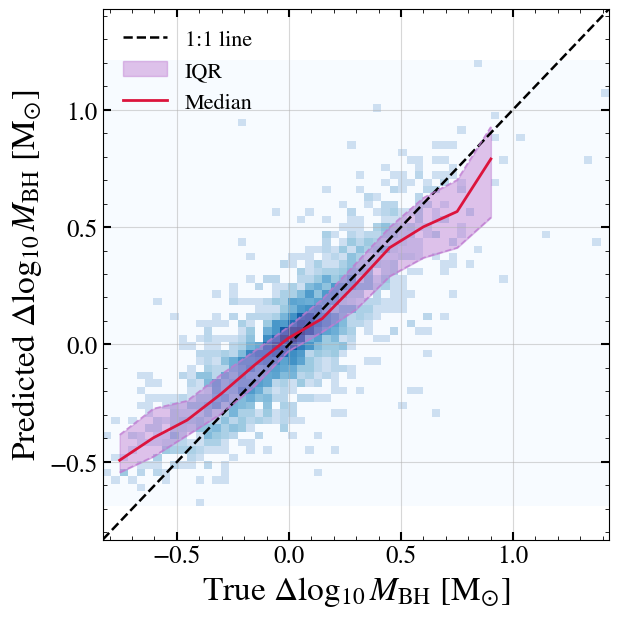

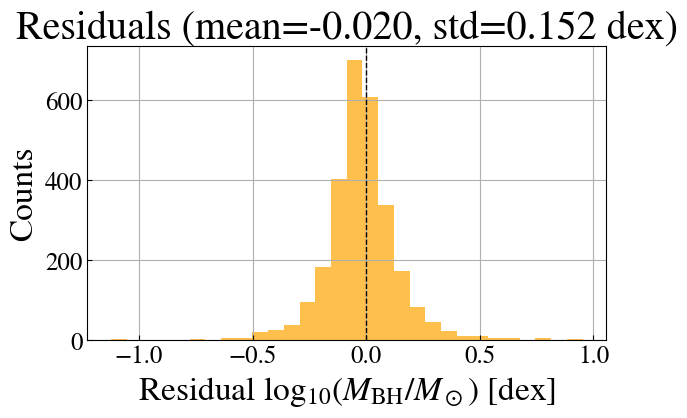

In [ ]:
# Run simple diagnostic checks on the validation set
# Output common metrics such as R^2, RMSE, and baseline RMSE

print(np.min(y_val), np.max(y_val))

y_true = y_val_tensor.cpu().numpy().flatten()
y_pred = val_preds_np  # already flattened

r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
print(f"R2 = {r2:.3f}")

print("True std:", np.std(y_true))
print("Pred std:", np.std(y_pred))
print("True mean:", np.mean(y_true))
print("Pred mean:", np.mean(y_pred))


y_train_mean = np.mean(y_train_scaled)

baseline_preds = np.full_like(y_val_scaled, y_train_mean)
baseline_mse = np.mean((y_val_scaled - baseline_preds)**2)
baseline_rmse = np.sqrt(baseline_mse)
model_rmse = np.sqrt(np.mean((y_val_scaled - val_preds_np)**2))

print(f"Baseline RMSE (dex): {baseline_rmse:.3f}")
print(f"Model RMSE (dex): {model_rmse:.3f}")
print(f"Improvement: {(1 - model_rmse/baseline_rmse)*100:.1f}%")


# Convert scaled predictions back to physical units (dex)
y_true_phys = y_scaler.inverse_transform(y_val_scaled.reshape(-1,1)).flatten()
y_pred_phys = y_scaler.inverse_transform(val_preds_np.reshape(-1,1)).flatten()

rmse_phys = np.sqrt(np.mean((y_true_phys - y_pred_phys)**2))
print(f"RMSE (dex) = {rmse_phys:.3f}")
print(f"Typical mass error ≈ factor of {10**rmse_phys:.2f}")


fig, ax = plt.subplots(figsize=(6,6))
# 2D histogram
h, xedges, yedges, img = ax.hist2d(y_true_phys, y_pred_phys, bins=60, cmap='Blues', norm=mcolors.PowerNorm(gamma=0.4))

# Binned IQR
bin_edges = np.linspace(y_true_phys.min(), y_true_phys.max(), 16)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

indices = np.digitize(y_true_phys, bin_edges) - 1

q25, q50, q75 = zip(*[
    np.percentile(y_pred_phys[indices == i], [25, 50, 75])
    if (indices == i).sum() > 5 else (np.nan, np.nan, np.nan)
    for i in range(15)
])

# 1:1 line
lims = [min(y_true_phys.min(), y_pred_phys.min()), max(y_true_phys.max(), y_pred_phys.max())]
ax.plot(lims, lims, 'k--', lw=1.8, label='1:1 line')

ax.fill_between(bin_centers, q25, q75, color='#bf7cd2', alpha=0.45, label='IQR')
ax.plot(bin_centers, q25, color='#bf7cd2', lw=1.2, ls='--', alpha=0.8)
ax.plot(bin_centers, q75, color='#bf7cd2', lw=1.2, ls='--', alpha=0.8)
ax.plot(bin_centers, q50, color='crimson', lw=2, label='Median')

ax.set(xlim=lims, ylim=lims,
       xlabel='True $\\Delta \\log_{10}M_{\\rm BH}$ [$\\rm M_{\\odot}$]',
       ylabel='Predicted $\\Delta \\log_{10}M_{\\rm BH}$ [$\\rm M_{\\odot}$]')
ax.legend(fontsize=16)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='x', which='minor', top=True, length=3)
ax.tick_params(axis='y', which='minor', right=True, length=3)
ax.tick_params(axis='x', which='major', top=True, width=1.5, length=6)
ax.tick_params(axis='y', which='major', right=True, width=1.5, length=6)
ax.grid(alpha=0.5)
plt.show()


# Residuals (dex)
residuals = y_true_phys - y_pred_phys

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color='orange', alpha=0.7)
plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Residual $\\log_{10}M_{\rm BH}$ $[\\rm M_{\\odot}]$ [dex]')
plt.ylabel('Counts')
plt.title(f'Residuals (mean={np.mean(residuals):.3f}, std={np.std(residuals):.3f} dex)')
plt.grid(True)
plt.show()

R² = 0.666
MSE = 0.346
RMSE = 0.588


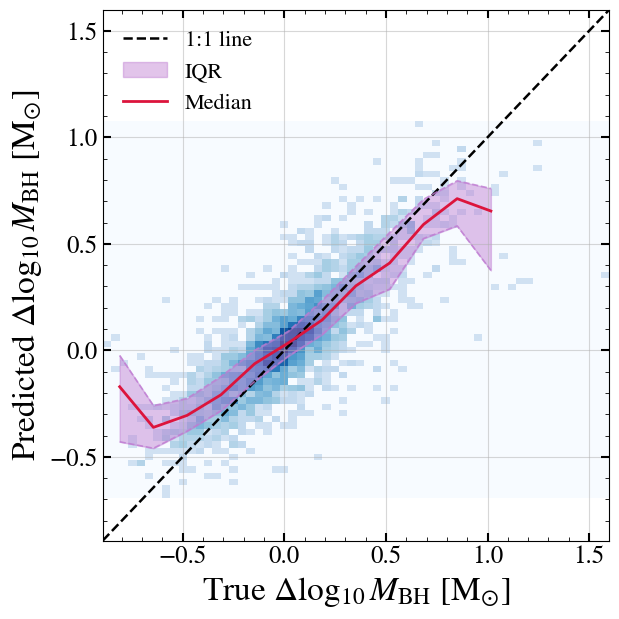

In [ ]:
# Repeat a similar analysis but for the fully held-out test set

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_preds_np = test_preds.cpu().numpy().flatten()
    test_labels_np = y_test_tensor.cpu().numpy().flatten()

mse = np.mean((test_preds_np - test_labels_np) ** 2)
rmse = np.sqrt(np.mean((test_preds_np - test_labels_np) ** 2))
r2 = 1 - np.sum((test_labels_np - test_preds_np)**2) / np.sum((test_labels_np - np.mean(test_preds_np))**2)
print(f'R2 = {r2:.3f}')
print(f'MSE = {mse:.3f}')
print(f'RMSE = {rmse:.3f}')

y_true_phys_test = y_scaler.inverse_transform(y_test_scaled.reshape(-1,1)).flatten()
y_pred_phys_test = y_scaler.inverse_transform(test_preds_np.reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(6,6))
# 2D histogram
h, xedges, yedges, img = ax.hist2d(y_true_phys_test, y_pred_phys_test, bins=60,cmap='Blues', norm=mcolors.PowerNorm(gamma=0.4))

# Binned IQR isochrones
bin_edges = np.linspace(y_true_phys_test.min(), y_true_phys_test.max(), 16)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

indices = np.digitize(y_true_phys_test, bin_edges) - 1

q25, q50, q75 = zip(*[
    np.percentile(y_pred_phys_test[indices == i], [25, 50, 75])
    if (indices == i).sum() > 5 else (np.nan, np.nan, np.nan)
    for i in range(15)
])

# 1:1 line
lims = [min(y_true_phys_test.min(), y_pred_phys_test.min()), max(y_true_phys_test.max(), y_pred_phys_test.max())]
ax.plot(lims, lims, 'k--', lw=1.8, label='1:1 line')

ax.fill_between(bin_centers, q25, q75, color='#bf7cd2', alpha=0.45, label='IQR')
ax.plot(bin_centers, q25, color='#bf7cd2', lw=1.2, ls='--', alpha=0.8)
ax.plot(bin_centers, q75, color='#bf7cd2', lw=1.2, ls='--', alpha=0.8)
ax.plot(bin_centers, q50, color='crimson', lw=2, label='Median')

ax.set(xlim=lims, ylim=lims,
       xlabel='True $\\Delta \\log_{10}M_{\\rm BH}$ [$\\rm M_{\\odot}$]',
       ylabel='Predicted $\\Delta \\log_{10}M_{\\rm BH}$ [$\\rm M_{\\odot}$]')
ax.legend(fontsize=16)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='x', which='minor', top=True, length=3)
ax.tick_params(axis='y', which='minor', right=True, length=3)
ax.tick_params(axis='x', which='major', top=True, width=1.5, length=6)
ax.tick_params(axis='y', which='major', right=True, width=1.5, length=6)
ax.grid(alpha=0.5)
plt.show()

In [19]:
feature_names = ['$M_{200}$', '$\\kappa_{\\rm co, gas}$', '$\\kappa_{\\rm co, \\star}$', 
                 '$f_{\\rm gas, 3kpc}$','$f_{\\rm gas, r200}$',
                 '$\\psi_{30 \\rm kpc}$', '$\\psi_{\\rm 2r50}$']

model_wrapped = TorchModelWrapper(model)
f = lambda x, y=None: model_wrapped.predict_last_hs(x, y)

print(average_event.shape)

(84, 7)


In [ ]:
def f_hs(x, y=None):
    """
    Takes input x of shape (N, T, F) and returns model predictions of shape (N, 1)
    """
    x_features = x[..., -len(feature_names):]   # Ensure only feature columns are passed
    return model_wrapped.predict_last_hs(x_features, y)


def timeshap_dataframe_single(X_instance, feature_names, entity_id):
    """
    X_instance: Array of shape (1, T, F) for a single galaxy.
    entity_id: The specific galaxy id or master index string/int.
    Returns: A Pandas DataFrame formatted exclusively for this single instance.
    """
    _, T, F = X_instance.shape

    rows = []
    for t in range(T):
        row = {
            'sequence_id': entity_id, # Maps exactly to the real galaxy ID string/int
            'time': t,
        }
        for f in range(F):
            row[feature_names[f]] = X_instance[0, t, f]
        rows.append(row)

    return pd.DataFrame(rows)


def run_batch_local_timeshap(
    f_hs,
    X,                      # Tensor of shape (N, T, F) for the whole subset
    average_sequence,       # (T, F) baseline array or DataFrame
    feature_names,
    entity_ids,             # Series/list/array of length N containing true IDs
    output_dir,
    nsamples=2000,
    rs=42
):
    os.makedirs(output_dir, exist_ok=True)
    N, T, F = X.shape
    
    # Ensure baseline sequence format is a structured DataFrame matching feature names
    if isinstance(average_sequence, np.ndarray):
        baseline_df = pd.DataFrame(average_sequence, columns=feature_names)
        baseline_df['time'] = np.arange(T) 
    else:
        baseline_df = average_sequence

    # Configuration Dictionaries
    pruning_dict = {'tol': 1e-6}    # Tolerance for pruning in TimeSHAP - set to very low to include all events
    event_dict = {'rs': rs, 'nsamples': nsamples}
    feature_dict = {'rs': rs, 'nsamples': nsamples}
    cell_dict = {'rs': rs, 'nsamples': nsamples, 'feat_threshold': 1e-2, 'event_threshold': 1e-2}   # Thresholds for significance in TimeSHAP cell-level explanations
    
    # Master lists to aggregate explanations across the subset
    all_event_data = []
    all_feature_data = []
    all_cell_data = []
    
    print(f"Beginning TimeSHAP batch calculation for {N} galaxies...")
    
    # Iterate through every galaxy one by one
    for i in tqdm(range(N), desc="Processing Galaxies"):
        current_id = entity_ids[i]
        
        # Isolate the single galaxy slice (preserves the 3D shape required)
        X_single = X[i:i+1, :, :] 
        
        # Build a local DataFrame specifically containing ONLY this instance
        X_df = timeshap_dataframe_single(X_single, feature_names, entity_id=current_id)
        X_df['time'] = X_df['time'].astype(int)
        
        # Run TimeSHAP's local_report function to get pruning, event, feature, and cell-level explanations
        pruning_data, event_data, feature_data, cell_level_data = calc_local_report(
            f_hs,
            X_df,
            pruning_dict,
            event_dict,
            feature_dict,
            cell_dict,
            baseline=baseline_df[feature_names],
            model_features=feature_names,
            entity_col='sequence_id',
            time_col='time',
        )
        
        # Insert the galaxy ID into a new column of each df to track which galaxy the explanations belong to
        event_data.insert(0, 'galaxy_id', current_id)
        feature_data.insert(0, 'galaxy_id', current_id)
        cell_level_data.insert(0, 'galaxy_id', current_id)
        
        # Map feature indices to their corresponding names 
        feature_map = {f"Feature {idx}": name for idx, name in enumerate(feature_names)}
        if 'Feature' in cell_level_data.columns:
            cell_level_data['Feature'] = cell_level_data['Feature'].map(feature_map).fillna(cell_level_data['Feature'])
        
        if 'Feature' in feature_data.columns:
            feature_data['Feature'] = feature_data['Feature'].map(feature_map).fillna(feature_data['Feature'])

        # Update master lists with current galaxy's explanations
        all_event_data.append(event_data)
        all_feature_data.append(feature_data)
        all_cell_data.append(cell_level_data)
            
    # Concatenate individual outputs into complete cross-galaxy master dataframes
    master_event_df = pd.concat(all_event_data, ignore_index=True)
    master_feature_df = pd.concat(all_feature_data, ignore_index=True)
    master_cell_df = pd.concat(all_cell_data, ignore_index=True)
    
    # Save complete datasets
    master_event_df.to_csv(os.path.join(output_dir, "local_event.csv"), index=False)
    master_feature_df.to_csv(os.path.join(output_dir, "local_feature.csv"), index=False)
    master_cell_df.to_csv(os.path.join(output_dir, "local_cell.csv"), index=False)
    
    return master_event_df, master_feature_df, master_cell_df

# Extract sequence baseline (T, F)
X_train_valid = np.where(X_train_scaled[..., -len(feature_names):] != 0.0, X_train_scaled[..., -len(feature_names):], np.nan)
average_sequence = np.nanmean(X_train_valid[..., -len(feature_names):], axis=0)   # Shape (T, F)
average_sequence = np.nan_to_num(average_sequence, nan=0.0)

# Reset galaxy index to lists/arrays to map consistently with numerical loops
galaxy_subset_data = combined_scaled['under_mid']   # Shape: (N, T, F)
galaxy_subset_ids = combined['under_mid']['master_idx']

# Look at under-massive black holes in the middle Ebind range
df_ev, df_feat, df_cell = run_batch_local_timeshap(
    f_hs,
    X=galaxy_subset_data,
    average_sequence=average_sequence,
    feature_names=feature_names,
    entity_ids=galaxy_subset_ids,
    output_dir='outputs_timeshap/under_mid'
)

# Reset galaxy index to lists/arrays to map consistently with numerical loops
galaxy_subset_data = combined_scaled['over_mid']    # Shape: (N, T, F)
galaxy_subset_ids = combined['over_mid']['master_idx']

# Look at over-massive black holes in the middle Ebind range
df_ev, df_feat, df_cell = run_batch_local_timeshap(
    f_hs,
    X=galaxy_subset_data,
    average_sequence=average_sequence,
    feature_names=feature_names,
    entity_ids=galaxy_subset_ids,
    output_dir='outputs_timeshap/over_mid'
)

dict_keys(['over_low', 'over_mid', 'over_high', 'under_low', 'under_mid', 'under_high'])
(7, 88) ['Event -88', 'Event -87', 'Event -86', 'Event -85', 'Event -84'] ...


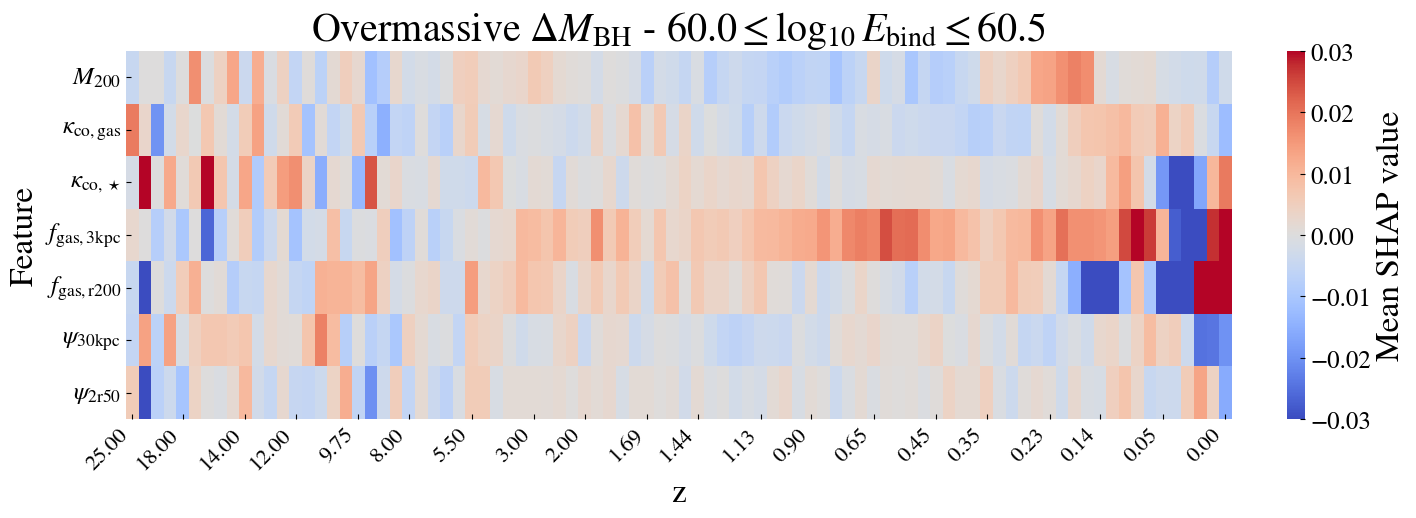

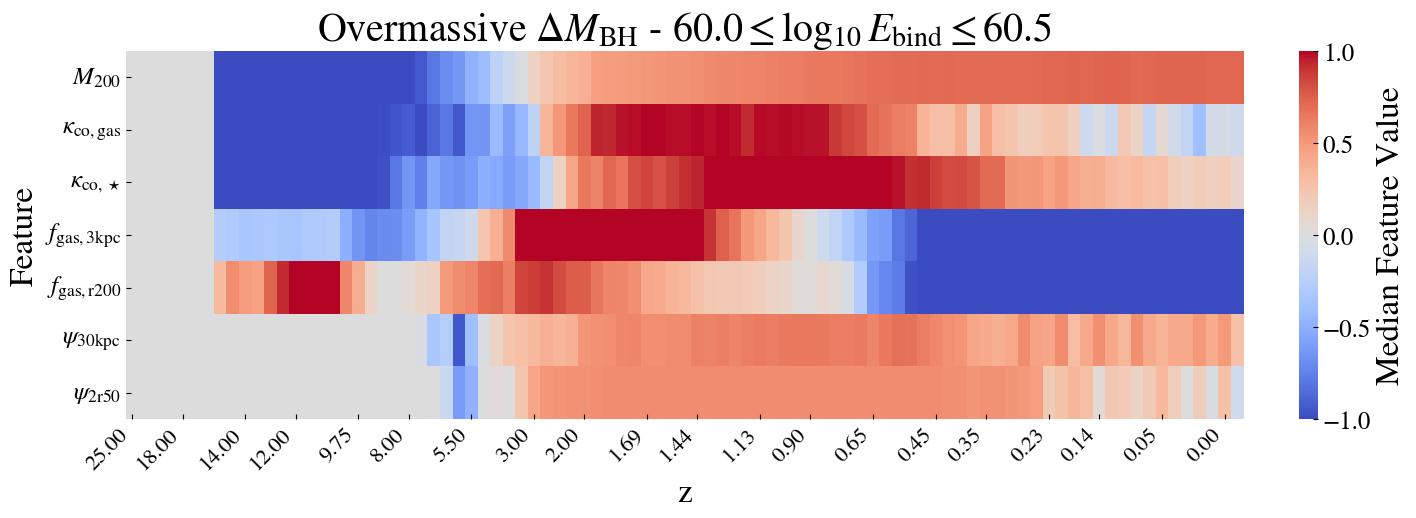

(7, 88) ['Event -88', 'Event -87', 'Event -86', 'Event -85', 'Event -84'] ...


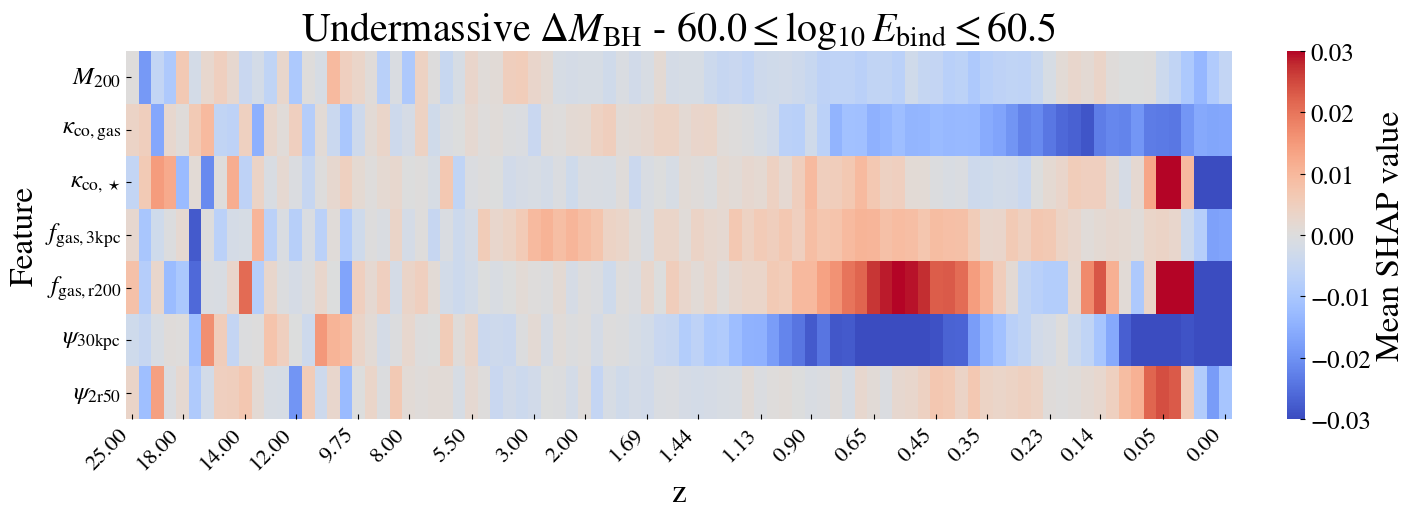

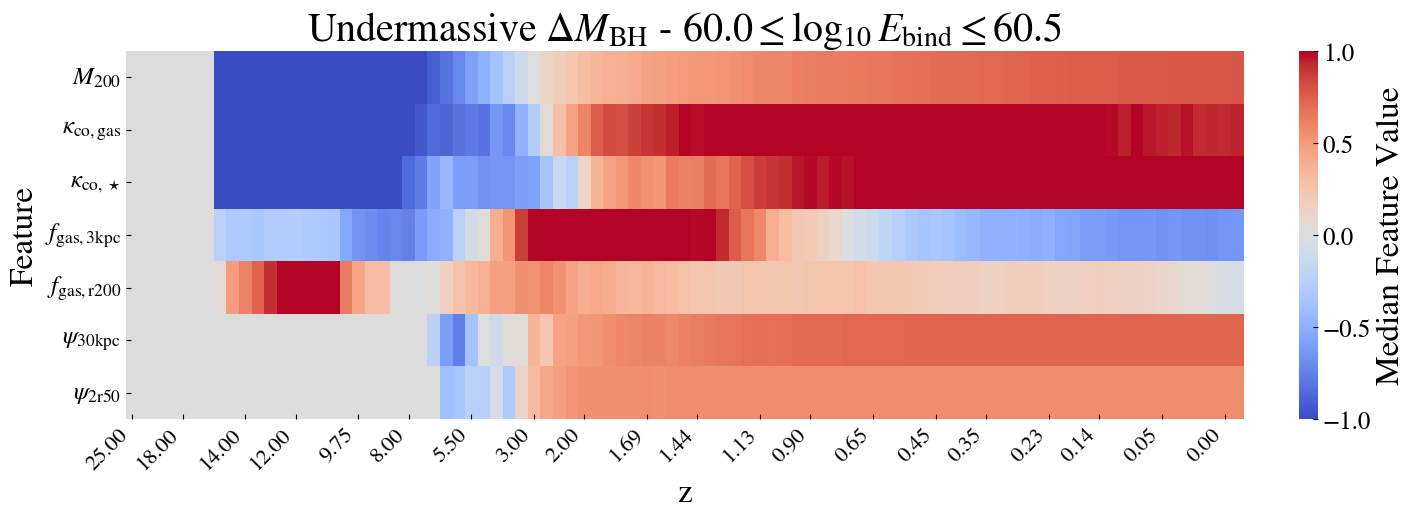

In [ ]:
def build_full_heatmap(df_cells, feature_names_subset, n_timesteps):
    """
    Build a (n_features, n_timesteps-1) heatmap with every possible event
    column present, filling pruned/missing events with NaN so column
    position always corresponds to the correct z index.
    """
    # Ignore pruned events and other non-event rows
    df = df_cells[
        ~df_cells['Event'].isin([0]) &
        (df_cells['Event'] != 'Pruned Events') &
        (df_cells['Event'] != 'Other Events')
    ].copy()

    heatmap = (df.groupby(['Feature', 'Event'], sort=False)['Shapley Value']
               .mean()
               .unstack('Event'))

    full_event_cols = [f'Event {i}' for i in range(-(n_timesteps - 1), 0)]
    heatmap = heatmap.reindex(columns=full_event_cols)

    sorted_cols = sorted(heatmap.columns,key=lambda col: int(str(col).replace('Event ', '').strip()))
    heatmap = heatmap[sorted_cols]

    # Force row order to match feature_names_subset, not alphabetical
    heatmap = heatmap.reindex(index=feature_names_subset)
    return heatmap

n_timesteps = len(z)

median_combined = {}
for name, arr in combined_scaled.items():
    if len(arr) == 0:
        print(f"Skipping {name} — empty")
        continue
    median_combined[name] = pd.DataFrame(np.median(arr, axis=0), columns=feature_names).T

print(median_combined.keys())

# Over-massive, mid Ebind
df_cells_over = pd.read_csv('outputs_timeshap/over_mid/local_cell.csv')
heatmap = build_full_heatmap(df_cells_over, feature_names, n_timesteps)
print(heatmap.shape, heatmap.columns.tolist()[:5], '...')

tick_col_idx = np.linspace(0, heatmap.shape[1] - 1, 20, dtype=int)
tick_t_vals  = z[1:][tick_col_idx]   # z[1:] since event range is -(T-1)..-1

fig, ax = plt.subplots(figsize=(14, 5), layout='compressed')
sns.heatmap(
    heatmap,
    center=0,
    cmap='coolwarm',
    ax=ax,
    cbar_kws={'label': 'Mean SHAP value'},
    vmin=-0.03,
    vmax=0.03
)
ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax.set_xticks(tick_col_idx + 0.5)
ax.set_xticklabels([f"{val:.2f}" for val in tick_t_vals], rotation=45, ha='right', fontsize=16)
ax.set_xlabel('z')
ax.set_ylabel('Feature')
ax.set_title('Overmassive $\\Delta M_{\\rm BH}$ - $60.0 \\leq \\log_{10}E_{\\rm bind} \\leq 60.5$')
plt.savefig('outputs_timeshap/overmassive_midEbind_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Over-massive feature value heatmap
fig, ax = plt.subplots(figsize=(14, 5), layout='compressed')
sns.heatmap(
    median_combined['over_mid'],
    center=0,
    cmap='coolwarm',
    ax=ax,
    xticklabels=z,
    cbar_kws={'label': 'Median Feature Value'},
    vmin=-1,
    vmax=1
)
ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax.set_xticks(tick_col_idx + 0.5)
ax.set_xticklabels([f"{val:.2f}" for val in tick_t_vals], rotation=45, ha='right', fontsize=16)
ax.set_xlabel('z')
ax.set_ylabel('Feature')
ax.set_title('Overmassive $\\Delta M_{\\rm BH}$ - $60.0 \\leq \\log_{10}E_{\\rm bind} \\leq 60.5$')
plt.savefig('outputs_timeshap/overmassive_midEbind_values_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()




# Under-massive, mid Ebind
df_cells_under = pd.read_csv('outputs_timeshap/under_mid/local_cell.csv')
heatmap = build_full_heatmap(df_cells_under, feature_names, n_timesteps)
print(heatmap.shape, heatmap.columns.tolist()[:5], '...')

tick_col_idx = np.linspace(0, heatmap.shape[1] - 1, 20, dtype=int)
tick_t_vals  = z[1:][tick_col_idx]   # z[1:] since event range is -(T-1)..-1

fig, ax = plt.subplots(figsize=(14, 5), layout='compressed')
sns.heatmap(
    heatmap,
    center=0,
    cmap='coolwarm',
    ax=ax,
    cbar_kws={'label': 'Mean SHAP value'},
    vmin=-0.03,
    vmax=0.03
)
ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax.set_xticks(tick_col_idx + 0.5)
ax.set_xticklabels([f"{val:.2f}" for val in tick_t_vals], rotation=45, ha='right', fontsize=16)
ax.set_xlabel('z')
ax.set_ylabel('Feature')
ax.set_title('Undermassive $\\Delta M_{\\rm BH}$ - $60.0 \\leq \\log_{10}E_{\\rm bind} \\leq 60.5$')
plt.savefig('outputs_timeshap/undermassive_midEbind_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Under-massive feature value heatmap
fig, ax = plt.subplots(figsize=(14, 5), layout='compressed')
sns.heatmap(
    median_combined['under_mid'],
    center=0,
    cmap='coolwarm',
    ax=ax,
    xticklabels=z,
    cbar_kws={'label': 'Median Feature Value'},
    vmin=-1,
    vmax=1
)
ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax.set_xticks(tick_col_idx + 0.5)
ax.set_xticklabels([f"{val:.2f}" for val in tick_t_vals], rotation=45, ha='right', fontsize=16)
ax.set_xlabel('z')
ax.set_ylabel('Feature')
ax.set_title('Undermassive $\\Delta M_{\\rm BH}$ - $60.0 \\leq \\log_{10}E_{\\rm bind} \\leq 60.5$')
plt.savefig('outputs_timeshap/undermassive_midEbind_values_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()